# GMM from scratch

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.fftpack import fft
from scipy.interpolate import make_splrep
from scipy.special import logsumexp

# from sklearn.mixture import GaussianMixture
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.utils import to_time_series_dataset
from tsfresh.feature_extraction import feature_calculators as feat_calc

import pyLasaDataset as lasa
# from hmmlearn import hmm
# from tqdm.auto import tqdm

Using LASA DataSet from /home/kir0ul/Projects/BayesDistanceClustering/.direnv/python-3.13/lib64/python3.13/site-packages/pyLasaDataset/resources/LASAHandwritingDataset/DataSet


### Hyperparameters

In [2]:
# seed = 0
seed = 42
seq_length = 1000
rng = np.random.default_rng(seed)
window_size = 10
window_step = 5

## Data

In [3]:
# series1 = rng.normal(loc=0, scale=1, size=(seq_length, 2))
# series2 = rng.normal(loc=5, scale=1, size=(seq_length, 2))
# series3 = rng.normal(loc=-3, scale=1, size=(seq_length, 2))
# data = np.stack([series1, series2, series3])
# data.shape

In [4]:
means = np.array(
    [
        [1, 3],
        [3, 1],
        [2.5, 2.5],
    ]
)
covs = np.eye(2) * 0.08
data = np.ones((means.shape[0], seq_length, 2)) * np.nan
for idx in range(means.shape[0]):
    data[idx, :, :] = rng.multivariate_normal(
        mean=means[idx, :], cov=covs, size=(seq_length)
    )
data.shape

(3, 1000, 2)

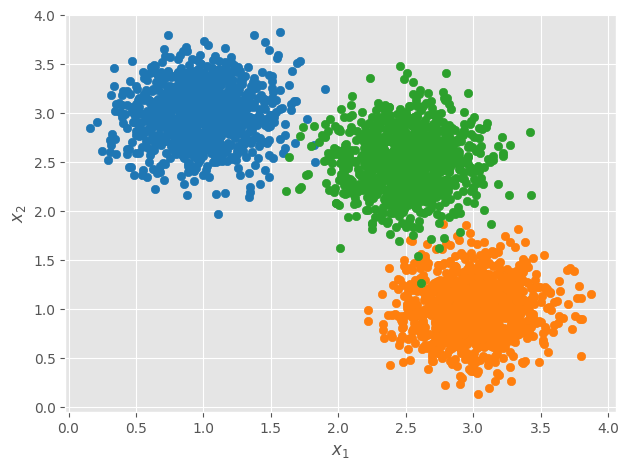

In [5]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(data.shape[0]):
        ax.scatter(data[idx, :, 0], data[idx, :, 1], color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

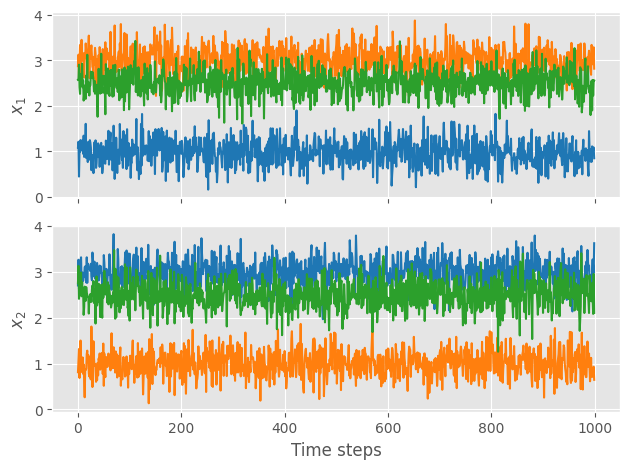

In [6]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(data.shape[-1], 1, sharex=True)
    for idx in range(data.shape[-1]):
        for jdx in range(data.shape[0]):
            ax[idx].plot(data[jdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

## Preprocessing & feature engineering

In [7]:
# dataset = to_time_series_dataset(data)
# dataset.shape

In [8]:
# scaler = TimeSeriesScalerMeanVariance()
# data_scaled = np.squeeze(scaler.fit_transform(data))
# data_scaled.shape

In [9]:
def sliding_window(series, window_size, step):
    windows = []
    for i in range(0, len(series) - window_size + 1, step):
        windows.append(series[i : i + window_size])
    return np.array(windows)

In [10]:
windows = []
for idx in range(data.shape[0]):
    data_sc_i = data[idx, :, :]
    windows.append(
        sliding_window(series=data_sc_i, window_size=window_size, step=window_step)
    )
windows = np.array(windows)
windows.shape

(3, 199, 10, 2)

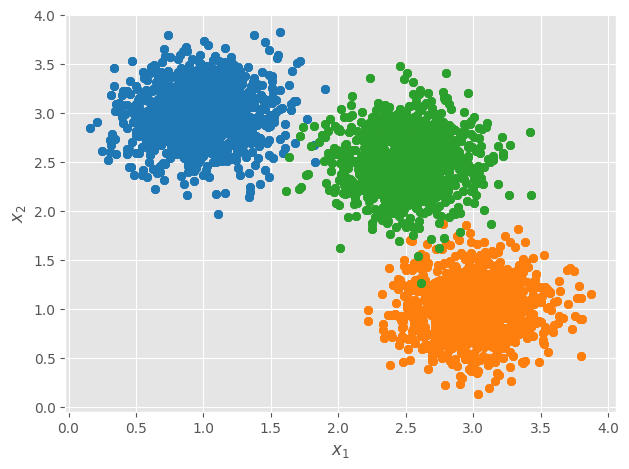

In [11]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        for jdx in range(windows.shape[1]):
            ax.scatter(
                windows[idx, jdx, :, 0], windows[idx, jdx, :, 1], color=cmap[idx]
            )
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

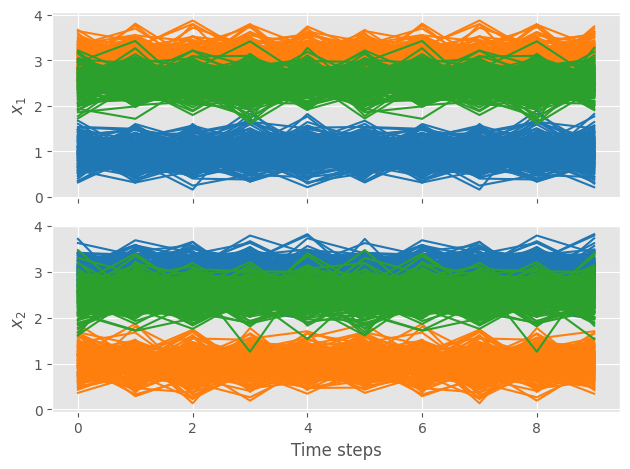

In [12]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            for kdx in range(windows.shape[1]):
                ax[idx].plot(windows[jdx, kdx, :, idx], c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [13]:
def loop_on_col(arr, funct, *args, **kwargs):
    res = []
    for col in range(arr.shape[1]):
        res.append(funct(arr[:, col], *args, **kwargs))
    return res

In [14]:
def extract_features(windows, lag=5, bins=10):
    features = []
    for win in windows:
        feats = [
            # np.mean(win),
            # np.std(win),
            # np.min(win),
            # np.max(win),
            # np.median(win),
            # np.percentile(win, 25),
            # np.percentile(win, 75),
            # *np.abs(fft(win)).flatten()[:5]
            *loop_on_col(arr=win, funct=feat_calc.abs_energy),
            feat_calc.absolute_sum_of_changes(win),
            feat_calc.autocorrelation(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.benford_correlation),
            # feat_calc.binned_entropy(x=win, max_bins=bins),
            feat_calc.c3(x=win, lag=lag),
            *loop_on_col(arr=win, funct=feat_calc.cid_ce, normalize=True),
            # *loop_on_col(arr=win, funct=feat_calc.fourier_entropy, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.kurtosis),
            *loop_on_col(arr=win, funct=feat_calc.lempel_ziv_complexity, bins=bins),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_above_mean),
            *loop_on_col(arr=win, funct=feat_calc.longest_strike_below_mean),
            feat_calc.mean_abs_change(win),
            *feat_calc.mean_change(win),
            *feat_calc.mean_second_derivative_central(win),
            *loop_on_col(
                arr=win,
                funct=feat_calc.percentage_of_reoccurring_datapoints_to_all_datapoints,
            ),
            *loop_on_col(
                arr=win, funct=feat_calc.percentage_of_reoccurring_values_to_all_values
            ),
            feat_calc.ratio_value_number_to_time_series_length(win),
            feat_calc.root_mean_square(win),
            feat_calc.sample_entropy(win),
            *loop_on_col(arr=win, funct=feat_calc.skewness),
            feat_calc.time_reversal_asymmetry_statistic(x=win, lag=lag),
            feat_calc.variation_coefficient(win),
        ]
        features.append(feats)
    return np.array(features)

In [15]:
features = []
for idx in range(windows.shape[0]):
    window_i = windows[idx, :, :]
    features.append(extract_features(window_i))
features = np.array(features)
features.shape

(3, 199, 33)

In [16]:
classes_gt = np.array(
    [np.ones(features.shape[1]) * idx for idx in range(features.shape[0])]
).flatten()
classes_gt

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1.

In [17]:
feat_mat = features.reshape(features.shape[0] * features.shape[1], features.shape[2])
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,11.571485,86.341783,18.752872,1.896223,0.833662,0.310942,13.308673,4.772010,4.906791,6.100929,...,0.0,0.0,0.0,1.0,2.212615,0.810930,-2.258800,0.562416,0.0,0.485177
1,12.709689,89.755904,18.707712,1.915477,0.807168,0.298659,14.080955,5.856260,3.712232,-0.400289,...,0.0,0.0,0.0,1.0,2.263466,0.599621,-0.188444,0.249853,0.0,0.462235
2,12.265597,89.192342,19.000588,1.867807,0.579097,0.298659,13.917389,4.974479,5.302902,0.647201,...,0.0,0.0,0.0,1.0,2.252309,0.949081,0.928191,0.500174,0.0,0.479429
3,12.378357,91.999116,19.420928,1.920861,0.695527,0.182761,14.602032,4.560505,5.329494,0.592182,...,0.0,0.0,0.0,1.0,2.284485,0.622530,0.688056,-0.209876,0.0,0.482678
4,9.853358,96.168471,21.260276,1.942633,0.637557,0.136829,15.368119,3.800681,4.320406,-0.893521,...,0.0,0.0,0.0,1.0,2.302410,0.530628,-0.322555,0.334846,0.0,0.530708
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,57.325784,63.977332,5.843352,0.054216,0.641886,0.555807,14.761605,3.617696,3.175069,-1.922034,...,0.0,0.0,0.0,1.0,2.462754,0.485508,0.016838,0.221448,0.0,0.173588
593,57.987973,69.507652,4.350880,-0.120396,0.555807,0.295657,15.928067,3.191300,4.837460,-0.321979,...,0.0,0.0,0.0,1.0,2.524833,0.117783,0.598811,-0.956856,0.0,0.131381
594,67.508181,62.238007,2.316396,-0.053877,0.305010,0.295657,16.431788,4.599328,3.630807,-1.145693,...,0.0,0.0,0.0,1.0,2.547020,0.117783,0.689216,0.204262,0.0,0.103646
595,59.244543,62.907607,2.809483,-0.700124,0.394728,0.295657,14.924374,4.439041,4.380154,3.159197,...,0.0,0.0,0.0,1.0,2.471357,0.117783,-0.961352,0.213899,0.0,0.098440


In [18]:
# scaler = StandardScaler()
# feat_mat = scaler.fit_transform(feat_mat)
# feat_mat = pd.DataFrame(feat_mat)
# feat_mat

## GMM clustering

In [19]:
def e_step(X, pi_mixing_prior, mu, Sigma, seed=None):
    eps = np.finfo(float).eps
    N, K = X.shape[0], pi_mixing_prior.shape[0]
    # gamma_resp = np.zeros((N, K))
    log_probs = np.zeros((N, K))

    for k in range(K):
        # gamma_resp[:, k] = pi_mixing_prior[k] * multivariate_normal(mean=mu[k], cov=Sigma[k], allow_singular=False, seed=seed).pdf(X)
        log_probs[:, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
            x=X, mean=mu[k], cov=Sigma[k], allow_singular=False
        )
    log_norm = logsumexp(log_probs, axis=1, keepdims=True)
    gamma_resp = np.exp(log_probs - log_norm)

    # # Normalize to get responsibilities
    # W_sum = gamma_resp.sum(axis=1, keepdims=True)
    # W_sum[W_sum == 0.0] = eps
    # gamma_resp /= W_sum
    return gamma_resp

In [20]:
def m_step(X, gamma_resp, reg_coef=1e-3):
    N, D = X.shape
    K = gamma_resp.shape[1]
    Nk = gamma_resp.sum(axis=0)  # soft counts

    # Update mixing coefficients
    pi_mixing_prior_new = Nk / N

    # Avoid division by zero
    # eps = np.finfo(float).eps
    # Nk[Nk == 0.0] = eps
    Nk = np.maximum(Nk, reg_coef)

    # Update means
    mu_new = (gamma_resp.T @ X) / Nk[:, None]

    # Update covariances
    Sigma_new = np.zeros((K, D, D))
    for j in range(K):
        diff = X - mu_new[j]

        # # weight each outer product by responsibility
        # Sigma_new[j] = (gamma_resp[:, j][:, None] * diff).T @ diff / Nk[j]

        # # regularization for numerical stability (optional, small jitter)
        # Sigma_new[j] += reg_coef*np.eye(D)

        # Constrain the covariance matrices to be diagonal
        var = (gamma_resp[:, j][:, None] * diff**2).sum(axis=0) / Nk[j]
        Sigma_new[j] = np.diag(var + reg_coef)

    # # Make sure the covariance matrices are symmetric positive definite
    # Sigma_new_spd = np.ones_like(Sigma_new)*np.nan
    # for j in range(K):
    #     # lower_tri = np.linalg.cholesky(Sigma_new[j])  # Cholesky Decomposition
    #     # Sigma_new_spd[j] = lower_tri @ lower_tri.T
    #     Sigma_new_spd[j] = np.linalg.cholesky(Sigma_new[j])  # Cholesky Decomposition
    # Sigma_new = Sigma_new_spd

    # # Make covariance matrices diagonal
    # Sigma_new *= np.eye(D)

    return pi_mixing_prior_new, mu_new, Sigma_new

In [21]:
# def log_likelihood(X, pi_mixing_prior, mu, Sigma, seed=None):
#     eps = np.finfo(float).eps
#     N, K = X.shape[0], pi_mixing_prior.shape[0]
#     comp = np.zeros((N, K))
#     for j in range(K):
#         comp[:, j] = pi_mixing_prior[j] * multivariate_normal(mean=mu[j], cov=Sigma[j], allow_singular=False, seed=seed).pdf(X)

#     # sum over components then take log
#     s = comp.sum(axis=1)
#     s[s == 0.0] = eps
#     return np.sum(np.log(s))


def log_likelihood(X, pi_mixing_prior, mu, Sigma):
    N, K = X.shape[0], pi_mixing_prior.shape[0]
    log_probs = np.zeros((N, K))
    for k in range(K):
        log_probs[:, k] = np.log(pi_mixing_prior[k]) + multivariate_normal.logpdf(
            x=X,
            mean=mu[k],
            cov=Sigma[k],
            allow_singular=False,
        )
    # logsumexp over components, then sum over data points
    return logsumexp(log_probs, axis=1).sum()

In [22]:
def run_EM(X, K_components, max_iter=300, tol=1e-6, reg_coef=1e-3, seed=None):

    # Initialization
    N, D = X.shape
    pi_mixing_prior = np.ones(K_components) / K_components
    # pi_mixing_prior = np.random.uniform(size=K_components)
    # pi_mixing_prior = pi_mixing_prior/pi_mixing_prior.sum()
    # mu = np.random.rand(K_components, D) * 10.0
    kmeans_model = KMeans(n_clusters=K_components, random_state=seed).fit(X=X)
    mu = np.array(kmeans_model.cluster_centers_)
    # Sigma = np.array([np.eye(D) * rng.uniform(low=0, high=0.01, size=D) for _ in range(K_components)])
    Sigma = np.array([np.eye(D) for _ in range(K_components)])

    lls = []
    for it in range(max_iter):
        # E-step
        gamma_resp = e_step(
            X=X, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
        )

        # M-step
        pi_mixing_prior, mu, Sigma = m_step(
            X=X, gamma_resp=gamma_resp, reg_coef=reg_coef
        )

        # Log-likelihood
        ll = log_likelihood(X=X, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma)
        lls.append(ll)

        # # Visualization every few iterations
        # if it in (0, 1, 2, 4, 9, 14, 19, 24, 29):
        #     plot_gmm(X, mu, Sigma, title=f'GMM Contours — Iteration {it+1}')

        # Convergence check
        if it > 0 and abs(lls[-1] - lls[-2]) < tol:
            print(f"Converged at iteration {it + 1}")
            break

    with plt.style.context("ggplot"):
        fig, ax = plt.subplots()
        ax.plot(lls, marker=".", c="k")
        ax.set_title("Log-likelihood over EM iterations")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Log-likelihood")
        # ax.set_grid(True, alpha=0.3)
        plt.show()

    labels_pred = np.argmax(gamma_resp, axis=1)
    return mu, Sigma, gamma_resp, labels_pred, pi_mixing_prior

In [23]:
def predict(X, pi_mixing_prior, mu, Sigma, seed=None):
    gamma_resp = e_step(
        X=X, pi_mixing_prior=pi_mixing_prior, mu=mu, Sigma=Sigma, seed=seed
    )
    labels_pred = np.argmax(gamma_resp, axis=1)
    return gamma_resp, labels_pred

In [24]:
# max_iter = 300
# tol = 1e-6
reg_coef = 1e-6
K_components = data.shape[0]

Converged at iteration 2


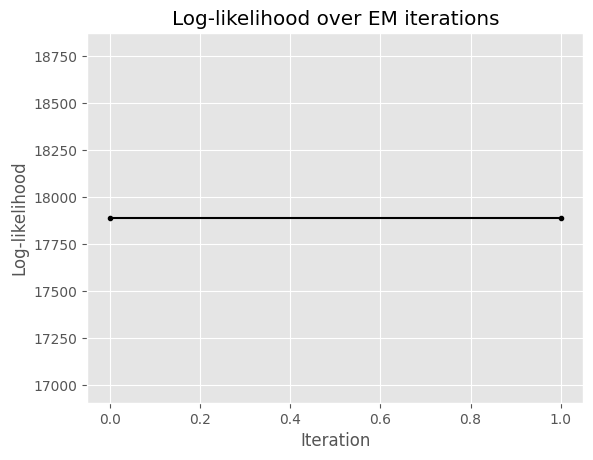

(array([[ 9.10336780e+01,  1.09107706e+01,  1.99843536e+01,
          1.84519710e+00,  2.54379447e-01,  5.69689403e-01,
          1.42110377e+01,  4.45389317e+00,  4.41726111e+00,
         -1.02345074e-01,  1.40554842e-01,  7.69346734e-01,
          7.68844221e-01,  2.78894472e+00,  2.65326633e+00,
          2.71356784e+00,  2.72864322e+00,  1.99843536e+00,
          3.43524828e-03, -4.52394723e-03,  5.32817860e-06,
          1.66818187e-03,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
          2.25677740e+00,  7.36636396e-01,  6.88791274e-02,
         -3.08012975e-02,  0.00000000e+00,  5.16490125e-01],
        [ 1.03863425e+01,  9.01455459e+01,  2.00899576e+01,
          1.85070081e+00,  5.26799833e-01,  2.56986415e-01,
          1.39761857e+01,  4.39600137e+00,  4.37697694e+00,
          5.43450096e-02, -8.51002459e-03,  7.76381910e-01,
          7.70351759e-01,  2.70854271e+00,  2.84924623e+00,
          2.74874372e+00,  2.67336683e+

In [25]:
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    X=feat_mat.to_numpy(), K_components=K_components, reg_coef=reg_coef, seed=seed
)
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

In [26]:
# K_components = 3
# gmm = GaussianMixture(n_components=K_components, random_state=seed)
# gmm.fit(feat_mat)
# # labels = gmm.fit_predict(features_scaled)
# clust_labels_pred = gmm.predict(feat_mat)
# proba = gmm.predict_proba(feat_mat)
# # print("Cluster labels (model-based):", labels)
# clust_labels_pred, np.round(proba)

In [27]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [28]:
# gmm.means_.shape, gmm.covariances_.shape

In [29]:
# with plt.style.context("ggplot"):
#     cmap = plt.colormaps["tab10"].colors
#     fig, ax = plt.subplots()
#     for idx in range(data.shape[0]):
#         ax.scatter(data[idx, :, 0], data[idx, :, 1], color="k", alpha=0.4)
#     ax.set_xlabel(f"$x_1$")
#     ax.set_ylabel(f"$x_2$")

#     # xg, yg = np.meshgrid(np.linspace(-5, 15, 100), np.linspace(-5, 15, 100))
#     # pos = np.dstack((xg, yg))
#     # for jdx in range(K_components):
#     #     rv = rng.multivariate_normal(
#     #         mean=gmm.means_[jdx], cov=gmm.covariances_[jdx]
#     #     )
#     #     # ax.contour(xg, yg, rv.pdf(pos), levels=5, colors=cmap[jdx], alpha=0.8)
#     #     ax.scatter(gmm.means_[jdx, 0], gmm.means_[jdx, 1], c="k")#, color=cmap[jdx], marker="x", s=100)

#     fig.tight_layout()
#     plt.show()

### Metrics

In [30]:
# accu = accuracy_score(y_true=classes_gt, y_pred=clust_labels_pred)
# print(f"Accuracy: {accu}")

In [31]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=classes_gt, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.8560787100370664
Completeness: 1.0
Fowlkes-Mallows index: 1.0
Homogeneity: 1.0
Mutual Information: 1.09861228866811
Adjusted mutual information: 1.0
Normalized Mutual Information: 1.0
Rand index: 1.0
Adjusted rand index: 1.0
V-measure: 1.0


In [32]:
pca = PCA(n_components=2)
feat_mat_pca = pca.fit_transform(feat_mat)
feat_mat_pca.shape

(597, 2)

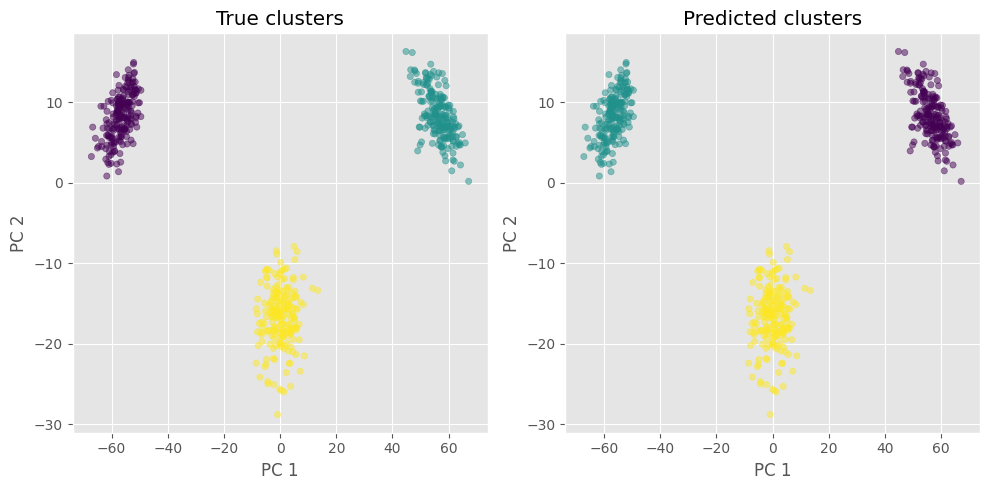

In [33]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=classes_gt, alpha=0.5, s=20)
    ax[0].set_title("True clusters")
    ax[1].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=clust_labels_pred, alpha=0.5, s=20
    )
    ax[1].set_title("Predicted clusters")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    fig.tight_layout()
    plt.show()

### New data

In [34]:
# new_data = np.random.normal(6, 1, 70)
# new_feat = np.array([np.mean(new_data), np.std(new_data)])[np.newaxis, :]
# new_feat

In [35]:
new_data = rng.multivariate_normal(
    mean=np.array([6, 1]), cov=covs, size=(seq_length * 2)
)
new_data.shape

(2000, 2)

In [36]:
# new_data_scaled = np.squeeze(scaler.transform(new_data))
# new_data_scaled.shape

In [37]:
new_windows = sliding_window(series=new_data, window_size=window_size, step=window_step)
new_windows.shape

(399, 10, 2)

In [38]:
new_feat_mat = pd.DataFrame(extract_features(new_windows))
new_feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,352.046601,9.502694,49.737845,1.978047,-0.261722,0.629360,104.833259,4.576306,4.242364,0.159998,...,0.0,0.0,0.0,1.0,4.251760,0.533298,-0.905536,-0.705453,0.0,0.729128
1,359.717527,7.981850,51.430119,1.978961,-0.261722,0.634733,108.294814,4.457998,3.941666,-1.151410,...,0.0,0.0,0.0,1.0,4.287770,0.585727,-0.483535,-0.310409,0.0,0.756028
2,359.562476,10.594420,50.143318,1.963167,-0.247033,0.772998,108.125874,3.967305,4.656275,0.534359,...,0.0,0.0,0.0,1.0,4.302074,0.414682,0.317852,-0.653875,0.0,0.723513
3,373.296037,10.785998,50.885636,1.970210,-0.263448,0.394349,114.151122,5.421117,3.682213,-0.526287,...,0.0,0.0,0.0,1.0,4.382248,0.432864,-0.013731,0.271370,0.0,0.718493
4,362.475228,10.788329,50.099635,1.967629,-0.247033,0.186993,109.412103,4.400979,4.571132,-0.231174,...,0.0,0.0,0.0,1.0,4.320090,0.576613,0.553924,0.742562,0.0,0.718446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
394,348.755681,12.289871,48.456396,1.937823,-0.261722,0.484978,102.930813,5.690672,3.709815,-0.691792,...,0.0,0.0,0.0,1.0,4.248797,0.333492,-0.746711,0.389435,0.0,0.705441
395,355.614787,14.640200,47.915991,1.961135,-0.261722,0.661996,106.818139,5.489582,4.444226,4.415827,...,0.0,0.0,0.0,1.0,4.302644,0.704447,-1.915737,-0.476135,0.0,0.678250
396,365.456437,9.587393,51.056055,1.975983,-0.247033,0.264458,110.808736,5.468791,4.244214,1.521926,...,0.0,0.0,0.0,1.0,4.330380,0.389071,1.448804,-0.188314,0.0,0.733949
397,363.952140,11.136882,50.205558,1.970025,-0.247033,0.761922,110.086136,3.471172,4.196379,-0.801453,...,0.0,0.0,0.0,1.0,4.330641,0.507248,-0.284669,-0.551076,0.0,0.717605


In [39]:
# new_feat_scaled = scaler.fit_transform(new_feat)
# new_feat_scaled = pd.DataFrame(new_feat_scaled)
# new_feat_scaled

In [40]:
# gmm.predict(new_feat_mat)

In [41]:
# np.round(gmm.predict_proba(new_feat_mat))

In [42]:
gamma_resp, labels_pred = predict(
    X=new_feat_mat.to_numpy(),
    pi_mixing_prior=pi_mixing_prior,
    mu=mu,
    Sigma=Sigma,
    seed=seed,
)
gamma_resp, labels_pred

(array([[1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.],
        ...,
        [1., 0., 0.],
        [1., 0., 0.],
        [1., 0., 0.]], shape=(399, 3)),
 array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 

In [43]:
# from tslearn.preprocessing import TimeSeriesScalerMeanVariance
# from tslearn.clustering import TimeSeriesKMeans
# from tslearn.utils import to_time_series_dataset

# np.random.seed(0)
# time = np.linspace(0, 10, 50)
# series = [np.sin(time + shift) for shift in np.linspace(0, 3, 10)]
# dataset = to_time_series_dataset(series)

# scaler = TimeSeriesScalerMeanVariance()
# dataset_scaled = scaler.fit_transform(dataset)

# model = TimeSeriesKMeans(n_clusters=3, metric="dtw", random_state=0)
# labels = model.fit_predict(dataset_scaled)

# print("Cluster Labels (Shape-Based):", labels)

## Lasa

In [44]:
resample_num = 2**10
print(f"Resampling to {resample_num} data points")
smoothing_factor = 0

Resampling to 1024 data points


In [45]:
def smooth_arr(arr, nb_points=256, smoothing_factor=0):
    index_ori = np.arange(start=0, stop=arr.shape[0])
    new_index = np.linspace(start=0, stop=arr.shape[0], num=nb_points)
    arr_smooth = make_splrep(x=index_ori, y=arr, s=smoothing_factor)(new_index)
    return arr_smooth

In [46]:
datasets = [lasa.DataSet.heee, lasa.DataSet.Line, lasa.DataSet.Saeghe]
X = None
classes_gt = None
for idx, data in enumerate(datasets):
    # dt = data.dt
    demos = data.demos
    demo_id = 0
    demo = demos[demo_id]
    pos = demo.pos.T
    pos_resampled = smooth_arr(
        arr=pos, nb_points=resample_num, smoothing_factor=smoothing_factor
    )
    # pos_resampled = pos
    if X is None:
        X = np.hstack((np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled))
        classes_gt = np.ones((pos_resampled.shape[0],), dtype=int) * idx
    else:
        # dist_from_last_point = np.abs(X[-1, :] - pos_resampled[0, :])
        pos_with_time = np.hstack(
            (np.arange(pos_resampled.shape[0])[:, np.newaxis], pos_resampled)
        )
        # X = np.vstack((X, pos_resampled - dist_from_last_point))
        X = np.vstack((X, pos_with_time))
        classes_gt = np.hstack(
            (classes_gt, np.ones(pos_resampled.shape[0], dtype=int) * idx)
        )
# X = np.hstack((np.arange(X.shape[0])[:, np.newaxis], X))
print(X.shape)
print(classes_gt.shape)
dataset = pd.DataFrame(
    {
        "t": X[:, 0],
        "pos_x": X[:, 1],
        "pos_y": X[:, 2],
        "y_cls": classes_gt,
    }
)
dataset

(3072, 3)
(3072,)


,t,pos_x,pos_y,y_cls
0,0.0,-31.414643,18.078238,0
1,1.0,-31.414425,18.078527,0
2,2.0,-31.413891,18.079220,0
3,3.0,-31.413022,18.080319,0
4,4.0,-31.411800,18.081830,0
...,...,...,...,...
3067,1019.0,0.001816,0.001816,2
3068,1020.0,0.000857,0.000857,2
3069,1021.0,0.000250,0.000250,2
3070,1022.0,-0.000002,-0.000002,2


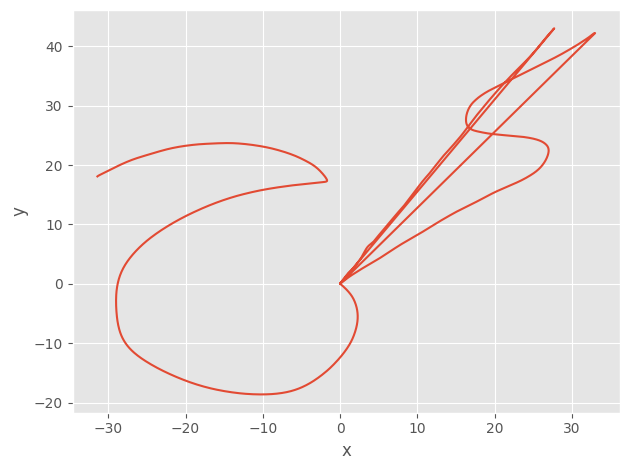

In [47]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots()
    ax.plot(dataset.pos_x, dataset.pos_y)  # , c=blobs[1], alpha=0.5, s=20)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    fig.tight_layout()
    plt.show()

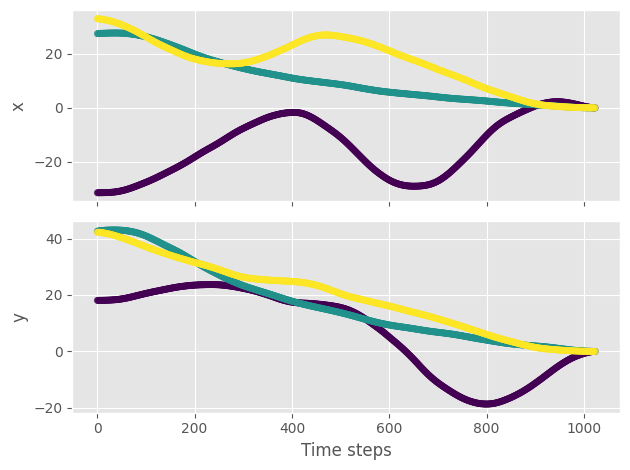

In [48]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(2, 1, sharex=True)
    ax[0].scatter(dataset.t, dataset.pos_x, c=dataset.y_cls, alpha=0.5, s=20)
    ax[1].scatter(dataset.t, dataset.pos_y, c=dataset.y_cls, alpha=0.5, s=20)
    ax[0].set_ylabel("x")
    ax[1].set_ylabel("y")
    ax[1].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [49]:
dataset[["pos_x", "pos_y"]]

,pos_x,pos_y
0,-31.414643,18.078238
1,-31.414425,18.078527
2,-31.413891,18.079220
3,-31.413022,18.080319
4,-31.411800,18.081830
...,...,...
3067,0.001816,0.001816
3068,0.000857,0.000857
3069,0.000250,0.000250
3070,-0.000002,-0.000002


In [50]:
# scaler = TimeSeriesScalerMeanVariance()
# ds_scaled = np.squeeze(scaler.fit_transform(dataset[["pos_x", "pos_y"]]))
# ds_scaled.shape

In [51]:
windows = sliding_window(
    series=dataset[["pos_x", "pos_y"]], window_size=window_size, step=window_step
)
windows.shape

(613, 10, 2)

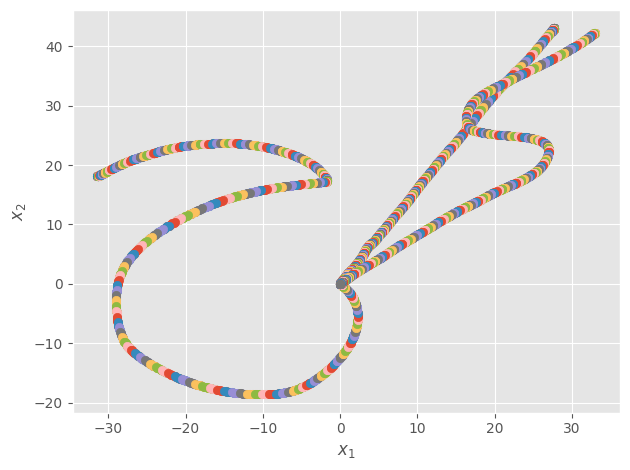

In [52]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

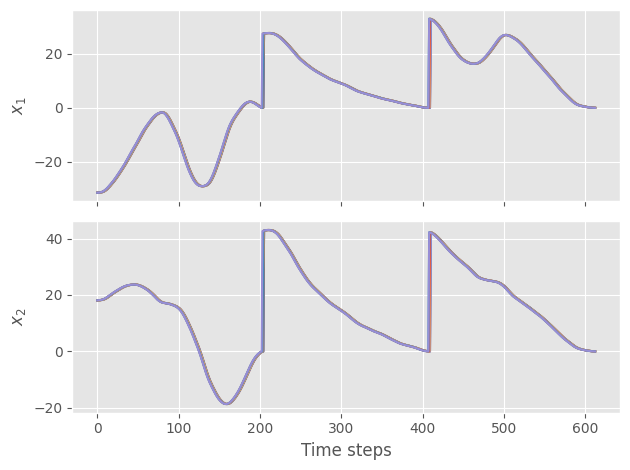

In [53]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[1]):
            ax[idx].plot(windows[:, jdx, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [54]:
feat_mat = extract_features(windows)
feat_mat.shape

(613, 33)

In [55]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,9865.556148,3270.477519,4.949394e+02,2.000000,0.062915,0.864123,-1.253636e+04,1.177736,1.154765,-0.436071,...,0.0,0.0,0.0,1.0,25.628142,0.242946,0.845209,0.781824,0.0,-3.714361
1,9857.342780,3275.774166,4.949550e+02,1.999999,0.062915,0.864123,-1.250983e+04,1.036605,1.032189,-1.273317,...,0.0,0.0,0.0,1.0,25.625297,0.242946,0.331213,0.282454,0.0,-3.722220
2,9844.628938,3283.517991,4.949662e+02,1.999999,0.062915,0.864123,-1.246938e+04,1.077593,1.068219,-1.013503,...,0.0,0.0,0.0,1.0,25.620448,0.242946,0.167125,0.105261,0.0,-3.733996
3,9827.260625,3293.153586,4.949550e+02,1.999998,0.062915,0.864123,-1.241542e+04,1.071804,1.056974,-1.043718,...,0.0,0.0,0.0,1.0,25.612901,0.242946,0.349061,0.235896,0.0,-3.749258
4,9801.228901,3305.906182,4.948904e+02,1.999997,0.062915,0.864123,-1.233687e+04,1.064599,1.055930,-1.084973,...,0.0,0.0,0.0,1.0,25.599937,0.242946,0.312708,0.227945,0.0,-3.770663
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
608,0.073421,0.073421,6.643991e-14,-1.032588,-0.094032,-0.094032,5.983441e-04,1.045884,1.045884,-1.191771,...,0.0,0.0,0.0,1.0,0.085686,0.117783,0.107998,0.107998,0.0,0.182068
609,0.037145,0.037145,7.201878e-14,-1.033487,-0.544187,-0.544187,2.103639e-04,1.047095,1.047095,-1.184862,...,0.0,0.0,0.0,1.0,0.060947,0.117783,0.139445,0.139445,0.0,0.220884
610,0.016108,0.016108,8.124751e-14,-1.001447,0.160269,0.160269,5.753194e-05,1.065637,1.065637,-1.103618,...,0.0,0.0,0.0,1.0,0.040135,0.117783,0.120446,0.120446,0.0,0.283233
611,0.005192,0.005192,6.583189e-14,-1.121654,0.815904,0.815904,8.517755e-06,1.026773,1.026773,-1.345637,...,0.0,0.0,0.0,1.0,0.022785,0.117783,0.156285,0.156285,0.0,0.468211


In [56]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=dataset.y_cls, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)

In [57]:
# scaler = StandardScaler()
# feat_scaled = scaler.fit_transform(features)
# feat_scaled = pd.DataFrame(feat_scaled)
# # feat_scaled = features
# feat_scaled

In [58]:
pca = PCA(n_components=2)
feat_mat_pca = pca.fit_transform(feat_mat)
feat_mat_pca.shape

(613, 2)

In [59]:
# gmm = GaussianMixture(n_components=K_components, random_state=seed)
# gmm.fit(feat_mat)
# clust_labels_pred = gmm.predict(feat_mat)
# proba = gmm.predict_proba(feat_mat)
# clust_labels_pred  #, np.round(proba)

Converged at iteration 47


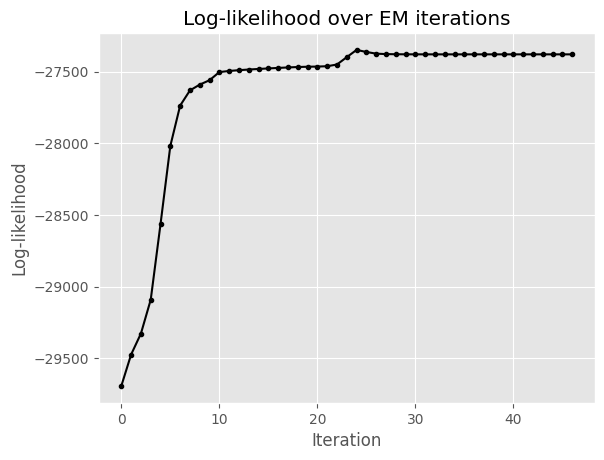

(array([[ 5.39673962e+03,  1.01424838e+04,  1.00394159e+02,
          1.92931373e+00,  4.86614567e-01,  1.94283679e-01,
          2.38905631e+04,  1.07836139e+00,  1.06346284e+00,
         -1.10856899e+00, -1.16776340e+00,  9.60520711e-01,
          9.72367481e-01,  5.02255648e+00,  5.04497034e+00,
          4.97180418e+00,  4.95493693e+00,  1.00394159e+01,
          1.24712048e-02,  1.71139983e-03, -5.23787166e-05,
         -6.41716694e-05,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
          2.73222458e+01,  2.39794921e-01, -3.82770513e-02,
         -5.26811018e-02,  0.00000000e+00,  1.90945885e-01],
        [ 4.04973892e+02,  4.75950984e+02,  3.44718223e+01,
         -4.18641290e-01,  3.96637935e-01,  3.42558213e-01,
         -6.63079961e-01,  1.17300392e+00,  1.14663776e+00,
         -7.96567847e-01, -8.16800575e-01,  9.35170648e-01,
          9.48286163e-01,  4.79205291e+00,  4.79132186e+00,
          5.15577755e+00,  5.20867814e+

In [60]:
reg_coef = 1e-1
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    X=feat_mat.to_numpy(), K_components=K_components, reg_coef=reg_coef, seed=seed
)
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

In [61]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [62]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [63]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: -0.12312566410067752
Completeness: 0.2291992002037639
Fowlkes-Mallows index: 0.5059037877526568
Homogeneity: 0.16929952289368325
Mutual Information: 0.18599273218114792
Adjusted mutual information: 0.19195523240220305
Normalized Mutual Information: 0.19474750102334568
Rand index: 0.5754566100502191
Adjusted rand index: 0.1554238412621935
V-measure: 0.19474750102334568


In [64]:
uncertainty = 1 - gamma_resp.max(axis=1)

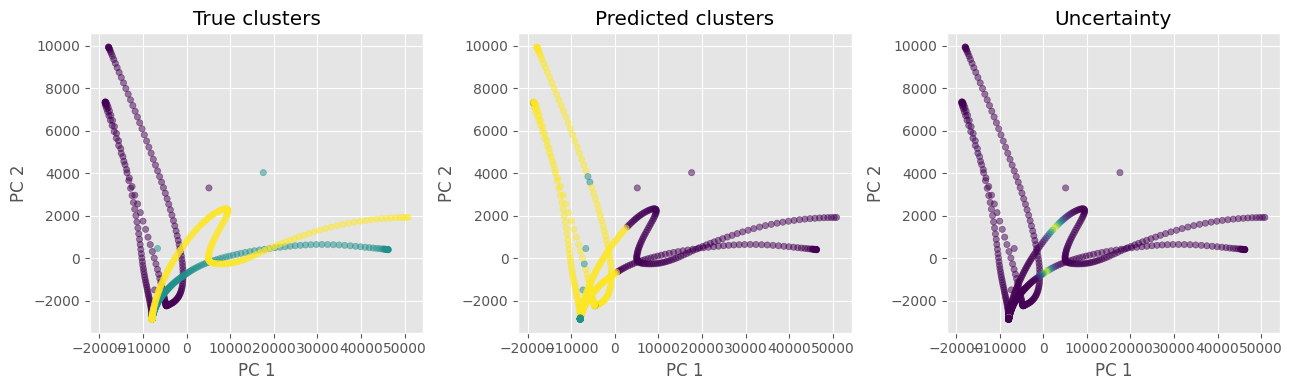

In [65]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    ax[0].scatter(feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=y_cls_win, alpha=0.5, s=20)
    ax[0].set_title("True clusters")
    ax[1].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=clust_labels_pred, alpha=0.5, s=20
    )
    ax[1].set_title("Predicted clusters")
    ax[2].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=uncertainty, alpha=0.5, s=20
    )
    ax[2].set_title("Uncertainty")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    fig.tight_layout()
    plt.show()

## Synthetic hierarchical (toy) data

In [66]:
# def plot_gaussian_hmm(
#     hmm, params, emissions, states, title="Emission Distributions", alpha=0.25
# ):
#     lim = 1.1 * abs(emissions).max()
#     XX, YY = jnp.meshgrid(jnp.linspace(-lim, lim, 100), jnp.linspace(-lim, lim, 100))
#     grid = jnp.column_stack((XX.ravel(), YY.ravel()))

#     plt.figure()
#     for k in range(hmm.num_states):
#         lls = hmm.emission_distribution(params, k).log_prob(grid)
#         plt.contour(
#             XX, YY, jnp.exp(lls).reshape(XX.shape), cmap=white_to_color_cmap(COLORS[k])
#         )
#         plt.plot(
#             emissions[states == k, 0],
#             emissions[states == k, 1],
#             "o",
#             mfc=COLORS[k],
#             mec="none",
#             ms=3,
#             alpha=alpha,
#         )

#     plt.plot(emissions[:, 0], emissions[:, 1], "-k", lw=1, alpha=alpha)
#     plt.xlabel("$y_1$")
#     plt.ylabel("$y_2$")
#     plt.title(title)
#     plt.gca().set_aspect(1.0)
#     plt.tight_layout()

In [67]:
def generate_two_level_hmm_sequence(
    seq_length,
    n_meta,
    n_sub,
    obs_dim,
    A_meta,
    A_sub,
    pi_meta,
    pi_sub,
    means,
    covariances,
    seed=None,
):
    """
    Generate sequence from a 2-level HMM.

    Parameters:
    - A_meta: (n_meta, n_meta) meta-state transition matrix
    - A_sub: (n_meta, n_sub, n_sub) sub-state transition (depends on meta)
    - pi_meta: (n_meta,) initial meta distribution
    - pi_sub: (n_meta, n_sub) initial sub distribution given meta
    - means: (n_meta, n_sub) observation means
    - covariances: (n_meta, n_sub, obs_dim, obs_dim) covariance matrices
    """
    rng = np.random.default_rng(seed)

    # Initialize arrays
    meta_states = np.zeros(seq_length, dtype=int)
    sub_states = np.zeros(seq_length, dtype=int)
    observations = np.zeros((seq_length, obs_dim))

    # Sample initial states
    meta_states[0] = rng.choice(n_meta, p=pi_meta)
    sub_states[0] = rng.choice(n_sub, p=pi_sub[meta_states[0]])

    # Generate first observation (multi-dimensional)
    observations[0] = rng.multivariate_normal(
        mean=means[meta_states[0], sub_states[0]],
        cov=covariances[meta_states[0], sub_states[0]],
    )

    # Generate rest of the sequence
    for t in range(1, seq_length):
        # Meta-state transition (depends only on previous meta)
        meta_states[t] = rng.choice(n_meta, p=A_meta[meta_states[t - 1]])

        # Check if meta-state changed
        if meta_states[t] != meta_states[t - 1]:
            # RESET: Sample sub-state from initial distribution
            sub_states[t] = rng.choice(n_sub, p=pi_sub[meta_states[t]])
        else:
            # Normal transition within same meta-state
            sub_states[t] = rng.choice(
                n_sub, p=A_sub[meta_states[t], sub_states[t - 1]]
            )

        # Multi-dimensional observation (depends on current meta and sub)
        observations[t] = rng.multivariate_normal(
            mean=means[meta_states[t], sub_states[t]],
            cov=covariances[meta_states[t], sub_states[t]],
            # size=(obs_dim),
        )

    return meta_states, sub_states, observations

In [68]:
n_meta = 3
n_sub = 4
obs_dim = 2

# Transition matrices
A_meta = np.array(
    [
        [0.8, 0.1, 0.1],  # from meta 0
        [0.1, 0.8, 0.1],  # from meta 1
        [0.1, 0.1, 0.8],  # from meta 2
    ]
)

# Sub-state transitions for each meta-state
A_sub = np.zeros((n_meta, n_sub, n_sub))
# Meta 0: tends to stay in same sub-state
A_sub[0] = np.array(
    [
        [0.7, 0.1, 0.1, 0.1],
        [0.1, 0.7, 0.1, 0.1],
        [0.1, 0.1, 0.7, 0.1],
        [0.1, 0.1, 0.1, 0.7],
    ]
)
# Meta 1: tends to increase sub-state
A_sub[1] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)
# Meta 2: tends to decrease sub-state
# A_sub[2] = np.array(
#     [
#         [0.4, 0.0, 0.0, 0.6],
#         [0.6, 0.4, 0.0, 0.0],
#         [0.0, 0.6, 0.4, 0.0],
#         [0.0, 0.0, 0.6, 0.4],
#     ]
# )
# Meta 2: tends to increase sub-state
A_sub[2] = np.array(
    [
        [0.4, 0.6, 0.0, 0.0],
        [0.0, 0.4, 0.6, 0.0],
        [0.0, 0.0, 0.4, 0.6],
        [0.6, 0.0, 0.0, 0.4],
    ]
)

# Initial distributions
pi_meta = np.array([0.34, 0.33, 0.33])  # uniform-ish
# pi_sub = np.array(
#     [
#         [0.4, 0.3, 0.2, 0.1],  # given meta 0
#         [0.1, 0.2, 0.3, 0.4],  # given meta 1
#         [0.25, 0.25, 0.25, 0.25],  # given meta 2
#     ]
# )
pi_sub = np.array(
    [
        [0.6, 0.1, 0.2, 0.1],  # given meta 0
        [0.2, 0.6, 0.1, 0.1],  # given meta 1
        [0.0, 0.2, 0.6, 0.2],  # given meta 2
    ]
)


# Multi-dimensional observation parameters
means = np.zeros((n_meta, n_sub, obs_dim))
covariances = np.zeros((n_meta, n_sub, obs_dim, obs_dim))

# # Make means distinct for different meta-sub combinations
# for m in range(n_meta):
#     for s in range(n_sub):
#         means[m, s] = m * 10 + s * 2  # e.g., meta0: 0,2,4,6; meta1: 10,12,14,16; etc.

# Define different (meta, sub) pairs to have distinct 2D Gaussian distributions
for m in range(n_meta):
    for s in range(n_sub):
        # Different centers for each state
        means[m, s, :] = [
            m * 10 + s * 2,
            m * 5 + s * 1.5,
            # m * 15 + s * 2.5,
            # m * 20 + s * 1,
            # m * 0 + s * 0,
        ]

        # Different covariance structures
        if m == 0:  # Meta 0: isotropic
            covariances[m, s] = np.eye(obs_dim) * (s + 1)
        elif m == 1:  # Meta 1: correlated
            covariances[m, s] = np.array([[2.0, 0.8], [0.8, 1.0]]) * (s + 1)
        else:  # Meta 2: anti-correlated
            covariances[m, s] = np.array([[2.0, -0.5], [-0.5, 1.0]]) * (s + 1)

In [69]:
# Generate sequence
meta_states, sub_states, observations = generate_two_level_hmm_sequence(
    seq_length=seq_length,
    n_meta=n_meta,
    n_sub=n_sub,
    obs_dim=obs_dim,
    A_meta=A_meta,
    A_sub=A_sub,
    pi_meta=pi_meta,
    pi_sub=pi_sub,
    means=means,
    covariances=covariances,
    seed=seed,
)

print(f"Meta states:  {meta_states}")
print(f"Sub states:   {sub_states}")
print(f"Observations:\n{np.round(observations[:10, :], 2)}\n [...]")

Meta states:  [2 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 0 1 1 1 0 0 0 0 2 2 0 0 0 0 0 0 0 2 2 2
 2 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 2 2 2 2 2 2 2 1 2 1 0 0 0 0 1 1
 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 1 2 1 0 0 0 0 0 0 0 0 0
 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2 2 1 1 1 2 2 2 2 2 0 0 0 0 0 0 1 1 1 1 1 1 1
 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 0 2 2 2 2 2 2 2 2 2 2 2 2 1 2 2 0 0 0 0 0
 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 2
 2 2 2 1 1 2 2 2 2 2 2 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2
 2 2 1 1 1 2 2 2 2 2 2 2 2 2 2 2 1 2 2 1 1 2 2 2 2 2 2 1 0 0 1 0 0 0 0 1 1
 2 2 2 0 0 0 0 0 1 0 0 0 0 0 2 2 2 2 2 2 2 1 1 2 2 2 1 1 2 2 0 0 0 1 1 2 2
 2 2 2 2 2 2 2 0 2 2 2 2 2 1 1 1 0 2 2 2 2 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 0 0 1 1 1 0 0 0 1 1 1 1 0 0 0 1 1
 1 1 1 1 1 0 0 0 0 2 2 1 1 1 1 2 2 2 2 2 0 0 0 0 0 0 0 0 1 2 1 0 1 1 1 1 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 2 2 2 2 2 0 0 0 0 1 1 1 1 0 0 1
 1 1 2 2 2 

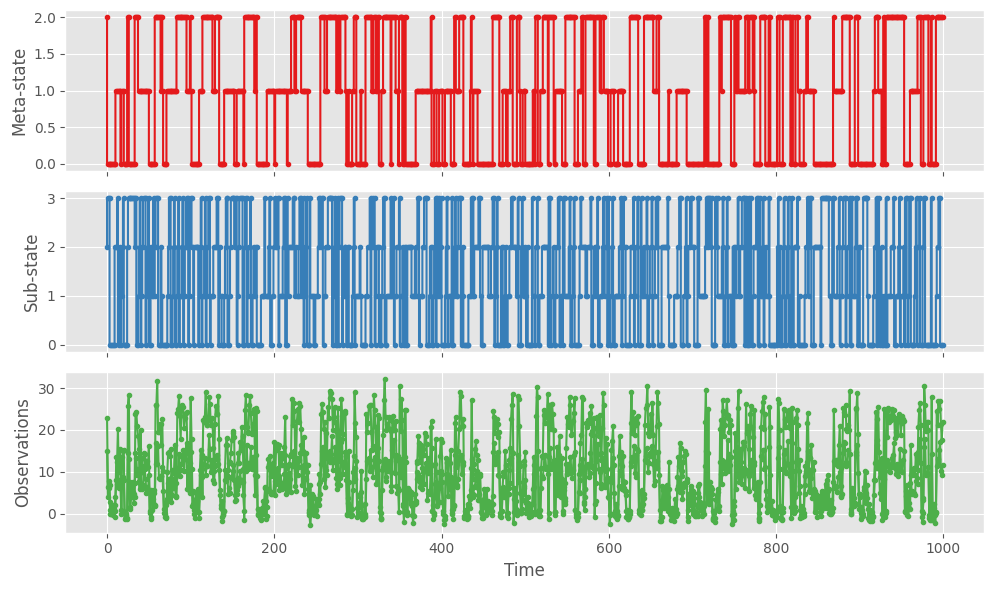

In [70]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["Set1"].colors
    fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 6))
    axes[0].step(meta_states, ".-", c=cmap[0])
    axes[0].set_ylabel("Meta-state")
    axes[1].step(sub_states, ".-", c=cmap[1])
    axes[1].set_ylabel("Sub-state")
    axes[2].plot(observations, ".-", c=cmap[2])
    axes[2].set_ylabel("Observations")
    axes[2].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

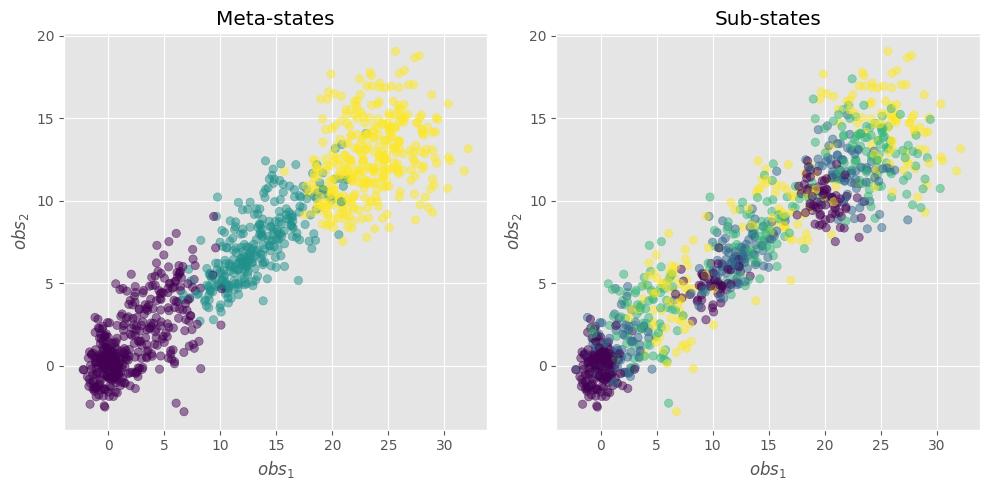

In [71]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))
    ax[0].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=meta_states)
    ax[1].scatter(observations[:, 0], observations[:, 1], alpha=0.5, c=sub_states)
    ax[0].set_title("Meta-states")
    ax[1].set_title("Sub-states")
    for axi in ax:
        axi.set_xlabel(f"$obs_1$")
        axi.set_ylabel(f"$obs_2$")
    fig.tight_layout()
    plt.show()

In [72]:
windows = sliding_window(series=observations, window_size=window_size, step=window_step)
windows.shape

(199, 10, 2)

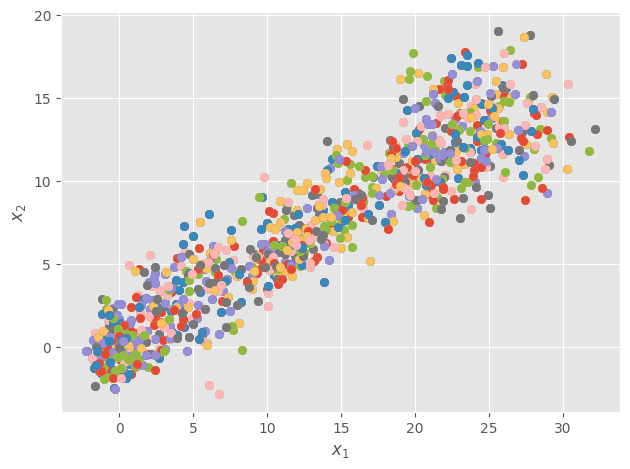

In [73]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots()
    for idx in range(windows.shape[0]):
        ax.scatter(windows[idx, :, 0], windows[idx, :, 1])  # , color=cmap[idx])
    ax.set_xlabel(f"$x_1$")
    ax.set_ylabel(f"$x_2$")
    fig.tight_layout()
    plt.show()

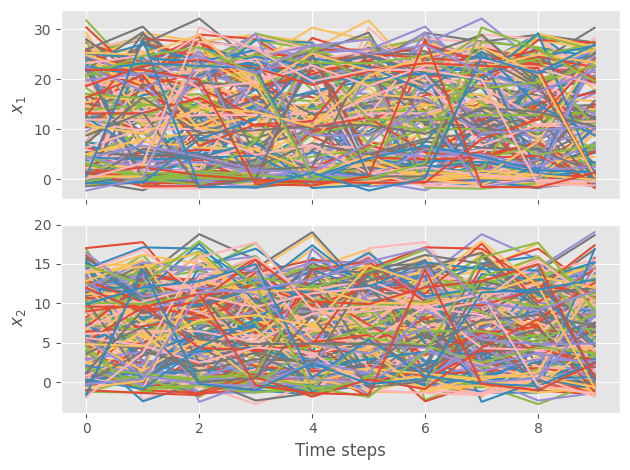

In [74]:
with plt.style.context("ggplot"):
    cmap = plt.colormaps["tab10"].colors
    fig, ax = plt.subplots(windows.shape[-1], 1, sharex=True)
    for idx in range(windows.shape[-1]):
        for jdx in range(windows.shape[0]):
            ax[idx].plot(windows[jdx, :, idx])  # , c=cmap[jdx])
        ax[idx].set_ylabel(f"$x_{idx + 1}$")
    ax[idx].set_xlabel("Time steps")
    fig.tight_layout()
    plt.show()

In [75]:
feat_mat = extract_features(windows)
feat_mat.shape

(199, 33)

In [76]:
for col in range(feat_mat.shape[1]):
    if np.any(np.isnan(feat_mat[:, col])):
        feat_mat = np.delete(arr=feat_mat, obj=col, axis=1)
feat_mat = pd.DataFrame(feat_mat)
feat_mat

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,674.144034,288.768962,22.945302,-0.601404,-0.025294,0.709353,42.842151,2.693654,2.743809,5.285951,...,0.0,0.0,0.0,1.0,6.938707,0.446287,2.166848,2.201973,0.0,1.482468
1,853.839443,300.424034,31.282725,-1.178621,0.822350,0.549349,43.408929,2.604282,2.211922,-0.467444,...,0.0,0.0,0.0,1.0,7.596919,0.530628,0.915748,0.612723,0.0,1.145392
2,1630.035048,565.258161,49.290146,0.132442,0.851382,0.019019,1076.773478,4.453304,4.761859,0.349244,...,0.0,0.0,0.0,1.0,10.476863,0.485508,-0.820156,-1.338630,0.0,0.549449
3,1019.156018,331.397361,33.759455,-0.247165,0.812934,-0.215303,384.065958,3.252008,3.355127,-2.422024,...,0.0,0.0,0.0,1.0,8.217522,0.650588,0.032248,-0.020620,0.0,1.118212
4,1826.075525,470.124963,47.942084,0.149716,0.668929,0.538402,884.372505,3.649669,3.957539,-0.289541,...,0.0,0.0,0.0,1.0,10.714944,0.650588,1.027928,1.086228,0.0,1.336376
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,4176.364355,1509.626892,72.531958,0.163397,0.417850,0.821654,4514.451082,3.270352,3.178794,-1.216681,...,0.0,0.0,0.0,1.0,16.861185,0.318454,-0.761906,-0.714757,0.0,0.717187
195,3353.568580,976.437972,69.817192,-0.663680,0.735572,0.647613,1811.349533,3.024716,2.983793,-1.897274,...,0.0,0.0,0.0,1.0,14.713950,0.530628,-0.274425,-0.039729,0.0,0.944339
196,2149.030823,524.365684,53.009853,0.622730,0.889971,0.838043,1667.071771,3.892127,4.223440,-1.902764,...,0.0,0.0,0.0,1.0,11.561567,0.832909,0.566409,0.549852,0.0,1.459131
197,2572.108998,652.167538,57.483838,-1.035887,0.664865,0.979193,4.801465,3.745439,3.893816,-2.081256,...,0.0,0.0,0.0,1.0,12.697001,0.864997,0.518057,0.449871,0.0,1.398710


In [77]:
pca = PCA(n_components=2)
feat_mat_pca = pca.fit_transform(feat_mat)
feat_mat_pca.shape

(199, 2)

### Meta-states clustering

In [78]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=meta_states, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)
y_cls_win

array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 0,
       1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
       2, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 0,
       1])

In [79]:
# gmm = GaussianMixture(n_components=n_meta, random_state=seed)
# gmm.fit(feat_mat)
# clust_labels_pred = gmm.predict(feat_mat)
# proba = gmm.predict_proba(feat_mat)
# clust_labels_pred  #, np.round(proba)

Converged at iteration 57


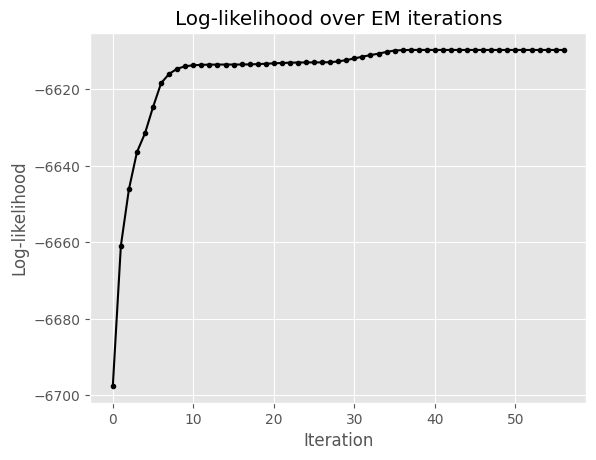

(array([[ 2.37315196e+03,  7.21064282e+02,  5.97946472e+01,
         -2.36671052e-01,  7.33385402e-01,  5.38153535e-01,
          1.25568573e+03,  3.19462089e+00,  3.34943669e+00,
         -7.77208560e-01, -8.24225012e-01,  7.29342131e-01,
          7.55431161e-01,  3.59626754e+00,  3.67634978e+00,
          4.07745132e+00,  3.90721037e+00,  5.97946472e+00,
         -1.73644771e-01, -1.08412692e-01, -2.83139893e-02,
         -4.12799945e-02,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
          1.23717362e+01,  4.48070766e-01,  1.82046432e-01,
          1.50332365e-01,  0.00000000e+00,  7.87871544e-01],
        [ 4.31449755e+03,  1.26815071e+03,  9.01227244e+01,
          6.25585796e-01,  6.44942864e-01,  7.74944765e-01,
          4.71491268e+03,  3.57594456e+00,  3.69994974e+00,
          5.67029029e-01,  1.87215556e-01,  7.26339990e-01,
          7.64233237e-01,  4.48659518e+00,  3.83180140e+00,
          2.63827873e+00,  2.94823796e+

In [80]:
reg_coef = 1e-3
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    X=feat_mat.to_numpy(), K_components=n_meta, reg_coef=reg_coef, seed=seed
)
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

In [81]:
# np.round(gmm.means_), np.round(gmm.covariances_)

In [82]:
y_cls_win, clust_labels_pred

(array([0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 2, 1, 0, 0, 0,
        1, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
        1, 1, 1, 0, 0, 0, 0, 1, 1, 2, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,
        0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1,
        2, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
        0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
        1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0, 1, 1, 1, 0, 0,
        1]),
 array([2, 2, 0, 2, 0, 0, 0, 0, 0, 2, 2, 1, 1, 2, 2, 0, 1, 1, 1, 0, 2, 2,
        1, 1, 1, 1, 0, 2, 0, 0, 0, 0, 1, 1, 1, 0, 2, 2, 2, 0, 0, 0, 0, 0,
        1, 1, 0, 2, 2, 2, 0, 1, 1, 1, 1, 1, 1, 2, 0, 0, 2, 0, 1, 1, 0, 1,
        1, 1, 0, 1, 1, 2, 2, 2, 0, 0, 0, 0, 2, 2, 2, 2, 0, 1, 1, 2, 2, 0,
        2, 2, 2, 2, 1, 0,

In [83]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.47949735029617285
Completeness: 0.4126040642452129
Fowlkes-Mallows index: 0.6217812458299471
Homogeneity: 0.5531450862960811
Mutual Information: 0.45126598380813365
Adjusted mutual information: 0.4665507143117618
Normalized Mutual Information: 0.47264843172807597
Rand index: 0.6893558702603929
Adjusted rand index: 0.36561966989778516
V-measure: 0.47264843172807597


In [84]:
uncertainty = 1 - gamma_resp.max(axis=1)

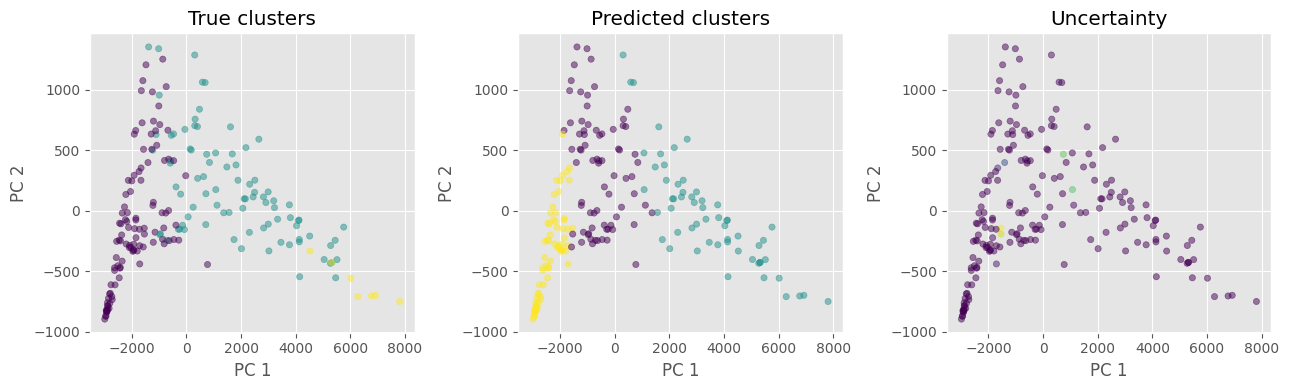

In [85]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    ax[0].scatter(feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=y_cls_win, alpha=0.5, s=20)
    ax[0].set_title("True clusters")
    ax[1].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=clust_labels_pred, alpha=0.5, s=20
    )
    ax[1].set_title("Predicted clusters")
    ax[2].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=uncertainty, alpha=0.5, s=20
    )
    ax[2].set_title("Uncertainty")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    fig.tight_layout()
    plt.show()

### Sub-states clustering

In [86]:
y_cls_win = np.round(
    np.mean(
        sliding_window(series=sub_states, window_size=window_size, step=window_step),
        axis=1,
        dtype=int,
    )
)
y_cls_win

array([1, 0, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 2, 2, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 2,
       1, 1, 2, 1, 0, 1, 1, 1, 2, 2, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1])

In [87]:
# gmm = GaussianMixture(n_components=n_sub, random_state=seed)
# gmm.fit(feat_mat)
# clust_labels_pred = gmm.predict(feat_mat)
# proba = gmm.predict_proba(feat_mat)
# clust_labels_pred  #, np.round(proba)

In [88]:
# np.round(gmm.means_), np.round(gmm.covariances_)

Converged at iteration 19


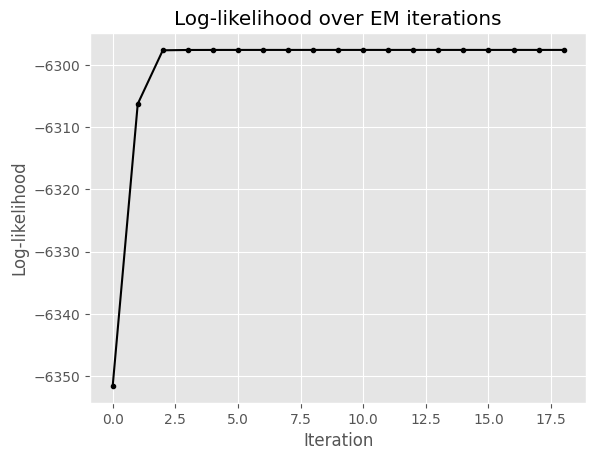

(array([[ 2.32659823e+03,  7.11199744e+02,  5.91242878e+01,
         -2.16731445e-01,  7.37917583e-01,  5.28292373e-01,
          1.21713677e+03,  3.22213194e+00,  3.36211686e+00,
         -7.43280912e-01, -8.10831161e-01,  7.25928246e-01,
          7.54629000e-01,  3.49181232e+00,  3.57769442e+00,
          4.14007094e+00,  3.95860540e+00,  5.91242878e+00,
         -2.17393727e-01, -1.26153280e-01, -1.84939494e-02,
         -3.60335004e-02,  0.00000000e+00,  0.00000000e+00,
          0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
          1.22652642e+01,  4.46348908e-01,  2.13572640e-01,
          1.82544005e-01,  0.00000000e+00,  7.90976633e-01],
        [ 4.97212729e+03,  1.46734104e+03,  9.99304753e+01,
          1.15661999e+00,  5.96845101e-01,  7.97307657e-01,
          6.25184218e+03,  4.06611124e+00,  4.12662341e+00,
          1.90903200e+00,  1.22973710e+00,  7.28061962e-01,
          7.44054865e-01,  3.63925939e+00,  2.92026739e+00,
          2.28034832e+00,  2.88035887e+

In [89]:
reg_coef = 1e-3
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior = run_EM(
    X=feat_mat.to_numpy(), K_components=n_sub, reg_coef=reg_coef, seed=seed
)
mu, Sigma, gamma_resp, clust_labels_pred, pi_mixing_prior

In [90]:
print(f"Silhouette: {metrics.silhouette_score(X=feat_mat, labels=clust_labels_pred)}")
print(
    f"Completeness: {metrics.completeness_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Fowlkes-Mallows index: {metrics.fowlkes_mallows_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Homogeneity: {metrics.homogeneity_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Mutual Information: {metrics.mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted mutual information: {metrics.adjusted_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Normalized Mutual Information: {metrics.normalized_mutual_info_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Rand index: {metrics.rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"Adjusted rand index: {metrics.adjusted_rand_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)
print(
    f"V-measure: {metrics.v_measure_score(labels_true=y_cls_win, labels_pred=clust_labels_pred)}"
)

Silhouette: 0.46408647545475923
Completeness: 0.0515066724424193
Fowlkes-Mallows index: 0.40961412953623266
Homogeneity: 0.10179152763154076
Mutual Information: 0.06735000296797639
Adjusted mutual information: 0.052804140332418745
Normalized Mutual Information: 0.06840188428307363
Rand index: 0.42667884878940154
Adjusted rand index: -0.024208765516088065
V-measure: 0.06840188428307363


In [91]:
uncertainty = 1 - gamma_resp.max(axis=1)

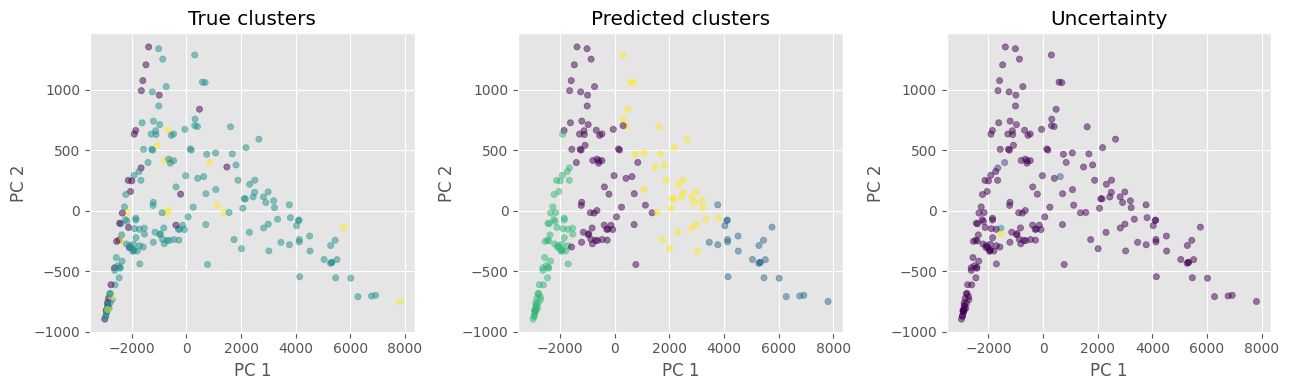

In [92]:
with plt.style.context("ggplot"):
    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(13, 4))
    ax[0].scatter(feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=y_cls_win, alpha=0.5, s=20)
    ax[0].set_title("True clusters")
    ax[1].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=clust_labels_pred, alpha=0.5, s=20
    )
    ax[1].set_title("Predicted clusters")
    ax[2].scatter(
        feat_mat_pca[:, 0], feat_mat_pca[:, 1], c=uncertainty, alpha=0.5, s=20
    )
    ax[2].set_title("Uncertainty")
    for axi in ax:
        axi.set_xlabel("PC 1")
        axi.set_ylabel("PC 2")
    fig.tight_layout()
    plt.show()